In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42) ## for reproducibility

## This notebook is divided into 4 subsections:
* Section 1: EDA: Exploratory Data Analysis
* Section 2: PCA and Dimensionality reduction
* Section 3: Machine learning: Model training
* Section 4: Model evaluation and metrics 

## First challenge: Cleaning this dataset
### Data Quality & Cleaning Questions
How do we deal with N/A values? — Several columns (Origin, Price, Number of Doors) have missing values.
How do we deal with outliers? — e.g., extreme prices or unusual year/mileage combinations.
How do we handle duplicates and missing values ?
When is the dataset considered clean and ready for ML?

## Exploratory Data Analysis: EDA
Given our 15 columns
**Brand, Model, Year, Condition, Mileage, Gearbox, Fiscal Power, Fuel, Equipment, Number of Doors, Origin, First Owner, Location, Sector, Price**
Let's try to answer the following questions:
### Price Analysis (Target Variable)
1. What is the distribution of car prices? — Is it **normal**, **skewed**, **multimodal**?
2. What is the average/median price by Brand? — Which brands command the highest prices?
3. How does car age (Year) affect price ? (Intuitively, the older the car, the lower the price is)

### Feature Relationships (correlation coefficients)
4. How does Mileage impact Price ? Do higher-mileage cars sell for significantly less? (Intuitively, the answer is **yes**)
5. Does Gearbox type (Manual vs. Automatic) affect price? — And is the effect consistent across brands?
6. Does Condition rating correlate with Price as expected? — Fair < Good < Very Good < Excellent? (We should expect that cars in **Very Good** or **Excellent** conditions to command a higher price)

### Market Composition
7. What are the most common Brands and Models? — Market share distribution.
8. What is the distribution of car Years? — Is the market dominated by recent or older cars?
9. What's the split between Manual vs. Automatic gearboxes?
10. What's the Diesel vs. Petrol distribution?

### Geographic Insights
11. Which Locations/cities have the most listings? — Casablanca, Rabat, Tanger, etc.
12. Do prices vary by Location? — Are cars in certain cities priced higher?
13. Does the Origin (WW in Morocco, Customs-cleared, etc.) affect pricing?

### Ownership & Equipment
14. Does First Owner (Yes/No) affect price? — Is there a premium for first-owner cars? (Normally, **yes**)
15. What are the most common Equipment features? — ABS, Airbags, Bluetooth, etc.
16. Do more equipped cars command higher prices? — Correlation between number of equipment features and price. (we should expect a **positive correlation coefficient**)

### Multivariate / Correlation
17. What are the strongest correlations with Price ? Heatmap of numerical/encoded features.

### First, importing the data and checking column names

In [84]:
df = pd.read_csv("cars_dataframe.csv")
column_names = list(df.columns)
rows, cols = df.shape
print(f"This dataset contains {rows} rows and {cols} columns")
df.info()

This dataset contains 101896 rows and 15 columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101896 entries, 0 to 101895
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Brand            101895 non-null  object 
 1   Model            101895 non-null  object 
 2   Year             101896 non-null  object 
 3   Condition        98313 non-null   object 
 4   Mileage          101895 non-null  object 
 5   Gearbox          101896 non-null  object 
 6   Fiscal Power     101616 non-null  object 
 7   Fuel             101896 non-null  object 
 8   Equipment        101896 non-null  object 
 9   Number of Doors  90481 non-null   float64
 10  Origin           89921 non-null   object 
 11  First Owner      87196 non-null   object 
 12  Location         101896 non-null  object 
 13  Sector           101650 non-null  object 
 14  Price            76413 non-null   float64
dtypes: float64(2), object(13)
memory usa

In [85]:
## As we can see there is a lot of cleaning to do
## Question: How do we handle NA data ?
## Question: How do we handle categorical data ?
## Question: How do we handle outliers ?
missing_values_count = df.isnull().sum()
print(missing_values_count)
total_cells = np.prod(df.shape)
total_missing = missing_values_count.sum()
percent_missing = (total_missing/total_cells) * 100
print(f'About {percent_missing:.2f}% of the data is missing.')

Brand                  1
Model                  1
Year                   0
Condition           3583
Mileage                1
Gearbox                0
Fiscal Power         280
Fuel                   0
Equipment              0
Number of Doors    11415
Origin             11975
First Owner        14700
Location               0
Sector               246
Price              25483
dtype: int64
About 4.43% of the data is missing.


In [86]:
missing_price_cars =df[df['Price'].isnull()]
missing_number_of_doors_cars =df[df['Number of Doors'].isnull()]
missing_number_of_doors_cars.head()
## Question: Based on the Brand, Model and Year we can find the number of door and fill in the corresponding value
## Fill missing 'Number of Doors' using mode from (Brand, Model, Year) groups, with fallback

def fill_doors(df):
    col = 'Number of Doors'
    
    # Compute mode for each grouping level (most specific → least specific)
    def group_mode(group_cols):
        return (
            df.dropna(subset=[col])
              .groupby(group_cols)[col]
              .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
        )
    
    mode_bmy = group_mode(['Brand', 'Model', 'Year'])   # most specific
    mode_bm  = group_mode(['Brand', 'Model'])            # fallback 1
    mode_b   = group_mode(['Brand'])                     # fallback 2
    overall_mode = df[col].mode().iloc[0]                # fallback 3

    def impute(row):
        if pd.notna(row[col]):
            return row[col]
        # Try (Brand, Model, Year)
        try:
            val = mode_bmy.loc[(row['Brand'], row['Model'], row['Year'])]
            if pd.notna(val):
                return val
        except KeyError:
            pass
        # Try (Brand, Model)
        try:
            val = mode_bm.loc[(row['Brand'], row['Model'])]
            if pd.notna(val):
                return val
        except KeyError:
            pass
        # Try (Brand)
        try:
            val = mode_b.loc[row['Brand']]
            if pd.notna(val):
                return val
        except KeyError:
            pass
        # Overall mode
        return overall_mode

    df[col] = df.apply(impute, axis=1)
    return df

df = fill_doors(df)

print(f"Missing 'Number of Doors' after imputation: {df['Number of Doors'].isnull().sum()}")

Missing 'Number of Doors' after imputation: 0


In [87]:
missing_number_of_doors_cars =df[df['Number of Doors'].isnull()]
assert missing_number_of_doors_cars.shape[0] == 0

In [88]:
df = df.dropna(subset=['Price'])
print(f"Remaining rows after dropping missing prices: {df.shape[0]}")
assert df['Price'].isnull().sum() == 0

Remaining rows after dropping missing prices: 76413


In [89]:
## Since we can't know the value for the column First Owner (could be anybody) we will replace N/A values with 'Unknown' for all records in which the First Owner is missing
df['First Owner'] = df['First Owner'].fillna('Unknown')
assert df['First Owner'].isna().sum() == 0

In [91]:
## We decided to drop the missing values where the condition is missing
df = df.dropna(subset=['Condition'])
assert df['Condition'].isnull().sum() == 0

In [92]:
df.Origin.unique()

array([nan, 'WW in Morocco', 'Customs-cleared car',
       'Car not yet customs-cleared', 'Imported New'], dtype=object)

In [93]:
df['Origin'] = df['Origin'].fillna('Unknown')
assert df['Origin'].isnull().sum() == 0

In [95]:
## Fill missing 'Fiscal Power' using mode from (Brand, Model, Year) groups, with fallback

def fill_fiscal_power(df):
    col = 'Fiscal Power'
    
    def group_mode(group_cols):
        return (
            df.dropna(subset=[col])
              .groupby(group_cols)[col]
              .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
        )
    
    mode_bmy = group_mode(['Brand', 'Model', 'Year'])   # most specific
    mode_bm  = group_mode(['Brand', 'Model'])            # fallback 1
    mode_b   = group_mode(['Brand'])                     # fallback 2
    overall_mode = df[col].mode().iloc[0]                # fallback 3

    def impute(row):
        if pd.notna(row[col]):
            return row[col]
        try:
            val = mode_bmy.loc[(row['Brand'], row['Model'], row['Year'])]
            if pd.notna(val):
                return val
        except KeyError:
            pass
        try:
            val = mode_bm.loc[(row['Brand'], row['Model'])]
            if pd.notna(val):
                return val
        except KeyError:
            pass
        try:
            val = mode_b.loc[row['Brand']]
            if pd.notna(val):
                return val
        except KeyError:
            pass
        return overall_mode

    df[col] = df.apply(impute, axis=1)
    return df

df = fill_fiscal_power(df)
print(f"Missing 'Fiscal Power' after imputation: {df['Fiscal Power'].isnull().sum()}")

assert df['Fiscal Power'].isnull().sum() == 0

Missing 'Fiscal Power' after imputation: 0


In [97]:
df['Sector'] = df['Sector'].fillna('Unknown')
assert df['Sector'].isnull().sum() == 0

In [98]:
df[
    df['Brand'].isnull()
]

,Brand,Model,Year,Condition,Mileage,Gearbox,Fiscal Power,Fuel,Equipment,Number of Doors,Origin,First Owner,Location,Sector,Price
6714,NaN,NaN,2019,Very Good,NaN,Manual,6 CV,35 000 - 39 999,"['Leather Seats', 'Alloy Wheels']",5.0,WW in Morocco,No,Meknès,Ville Nouvelle,215000.0


In [99]:
## Dropping rows with missing values for Brand and Model
df = df.drop(index=6714)  # 0-indexed

In [100]:
assert df['Brand'].isnull().sum() == 0

In [101]:
## Let's check for duplicates
df.duplicated().sum()

np.int64(1715)

In [103]:
## Droping duplicates values
df.drop_duplicates(inplace=True)
assert df.duplicated().sum() == 0

In [112]:
# See which "brands" are numeric
print(df[df['Brand'].str.isnumeric()]['Brand'].unique())

# Drop them
df = df[~df['Brand'].str.isnumeric()]
print(f"Rows remaining: {df.shape[0]}")


['75' '111' '76' '73' '74' '97' '77' '99' '72' '112']
Rows remaining: 72413


In [104]:
df.isna().sum()

Brand              0
Model              0
Year               0
Condition          0
Mileage            0
Gearbox            0
Fiscal Power       0
Fuel               0
Equipment          0
Number of Doors    0
Origin             0
First Owner        0
Location           0
Sector             0
Price              0
dtype: int64

### Price Analysis (Target Variable)
1. What is the distribution of car prices? — Is it **normal**, **skewed**, **multimodal**?
2. What is the average/median price by Brand? — Which brands command the highest prices?
3. How does car age (Year) affect price ? (Intuitively, the older the car, the lower the price is)

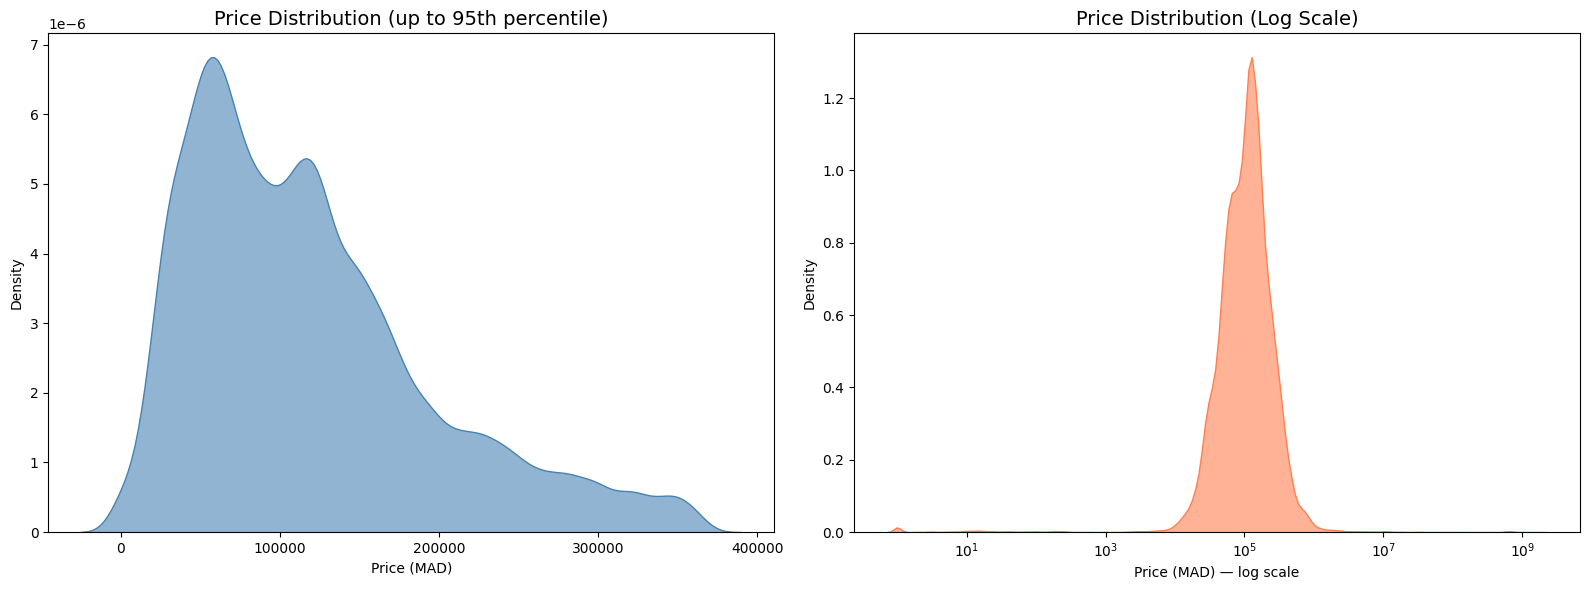

In [109]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Clipped to 95th percentile for a cleaner view
upper = df['Price'].quantile(0.95)
sns.kdeplot(data=df[df['Price'] <= upper], x='Price', fill=True, color='steelblue', alpha=0.6, ax=axes[0])
axes[0].set_title('Price Distribution (up to 95th percentile)', fontsize=14)
axes[0].set_xlabel('Price (MAD)')

# Right: Log scale to see the full range
sns.kdeplot(data=df, x='Price', fill=True, color='coral', alpha=0.6, ax=axes[1], log_scale=True)
axes[1].set_title('Price Distribution (Log Scale)', fontsize=14)
axes[1].set_xlabel('Price (MAD) — log scale')

plt.tight_layout()
plt.show()


2. What is the average/median price by Brand? — Which brands command the highest prices?


In [129]:
df.groupby("Brand").agg({"Price": "median"})

,Price
Brand,
AC,90000.0
Alfa Romeo,125000.0
Audi,228000.0
Autres,68000.0
BMW,200000.0
...,...
Volkswagen,140000.0
Volvo,165000.0
Zotye,57000.0


C:\Users\PC\AppData\Local\Temp\ipykernel_51764\898125327.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




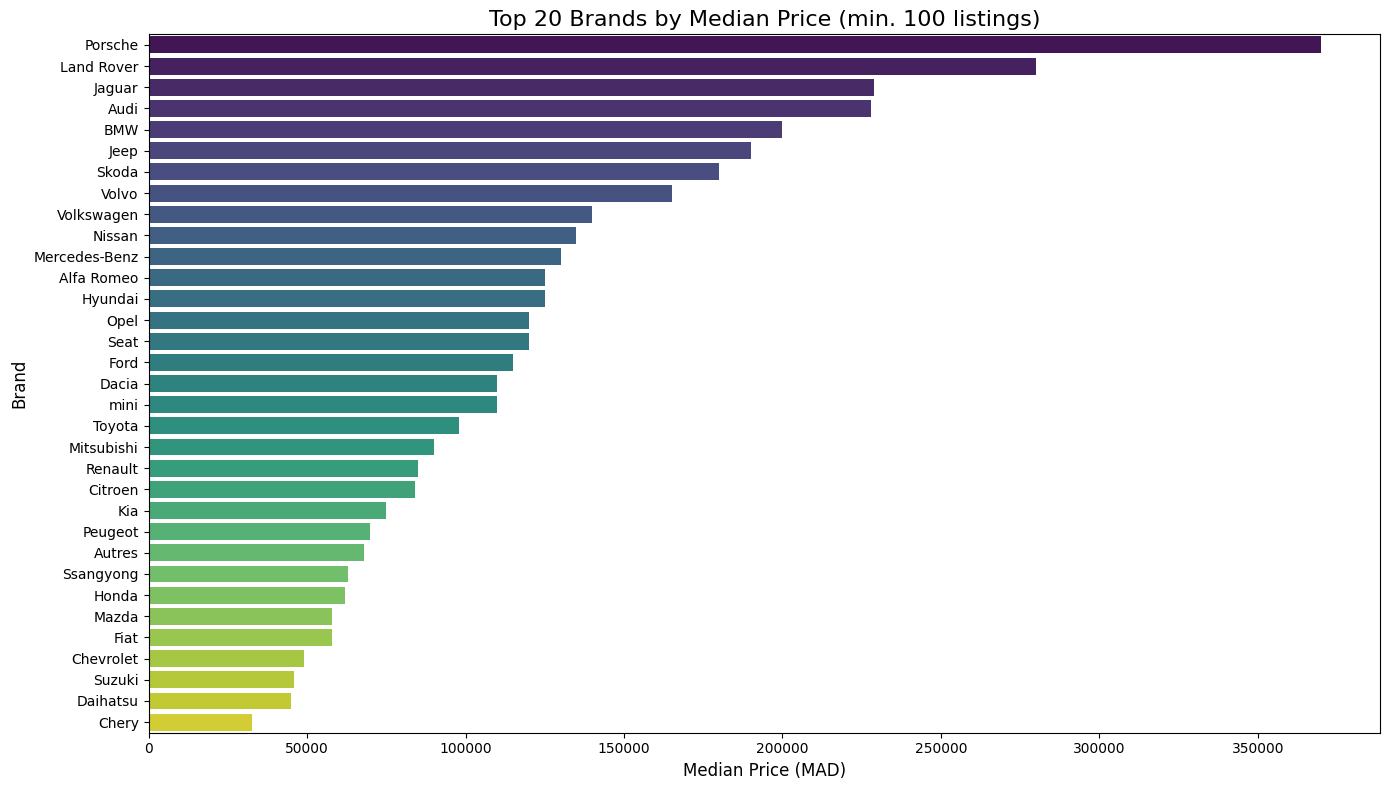

In [125]:
# Only include brands with at least 100 listings for reliability
brand_counts = df['Brand'].value_counts()
popular_brands = brand_counts[brand_counts >= 100].index
df_popular = df[df['Brand'].isin(popular_brands)]

# Use MEDIAN instead of mean — robust to outliers
median_price = df_popular.groupby('Brand')['Price'].median().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 8))
sns.barplot(x=median_price.values, y=median_price.index, palette='viridis', ax=ax)
ax.set_title('Top 20 Brands by Median Price (min. 100 listings)', fontsize=16)
ax.set_xlabel('Median Price (MAD)', fontsize=12)
ax.set_ylabel('Brand', fontsize=12)
plt.tight_layout()
plt.show()


3. How does car age (Year) affect price ? (Intuitively, the older the car, the lower the price is)

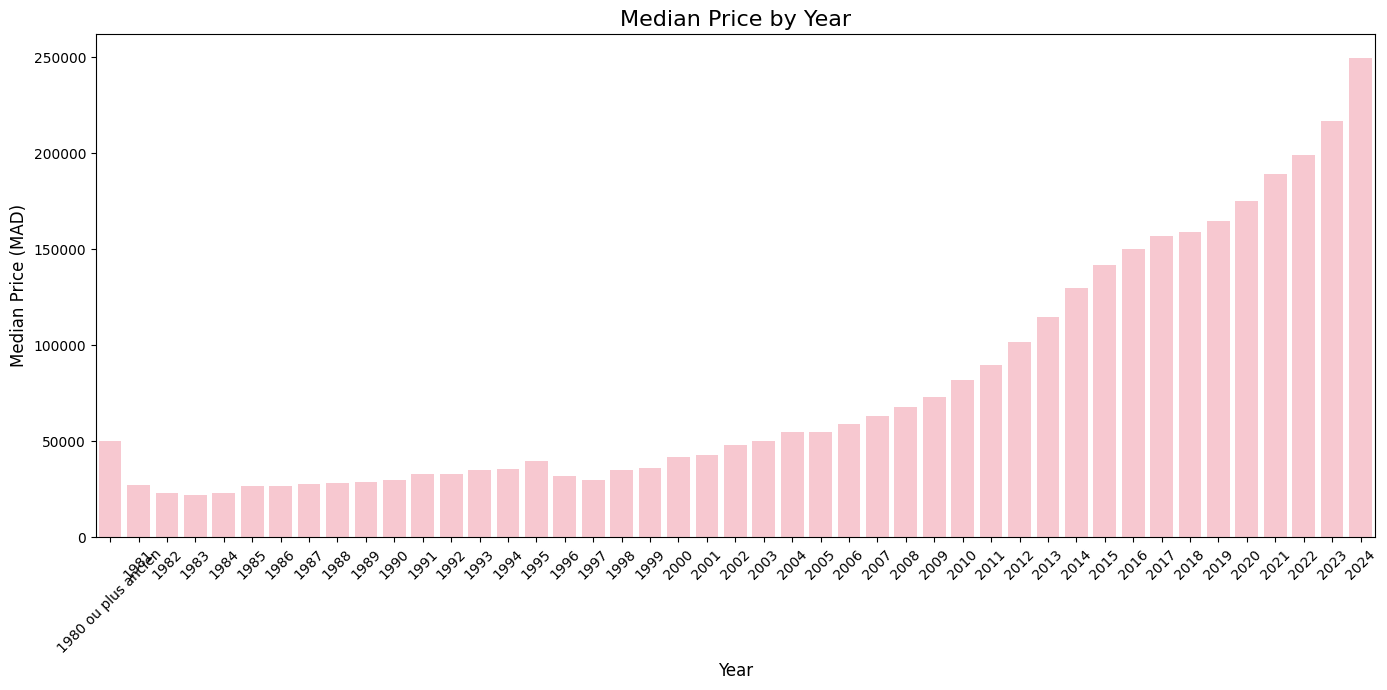

In [134]:
median_by_year = df.groupby('Year')['Price'].median().reset_index()

fig, ax = plt.subplots(figsize=(14, 7))
sns.barplot(data=median_by_year, x='Year', y='Price', color='pink', ax=ax)
ax.set_title('Median Price by Year', fontsize=16)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Median Price (MAD)', fontsize=12)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


C:\Users\PC\AppData\Local\Temp\ipykernel_51764\1935121795.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




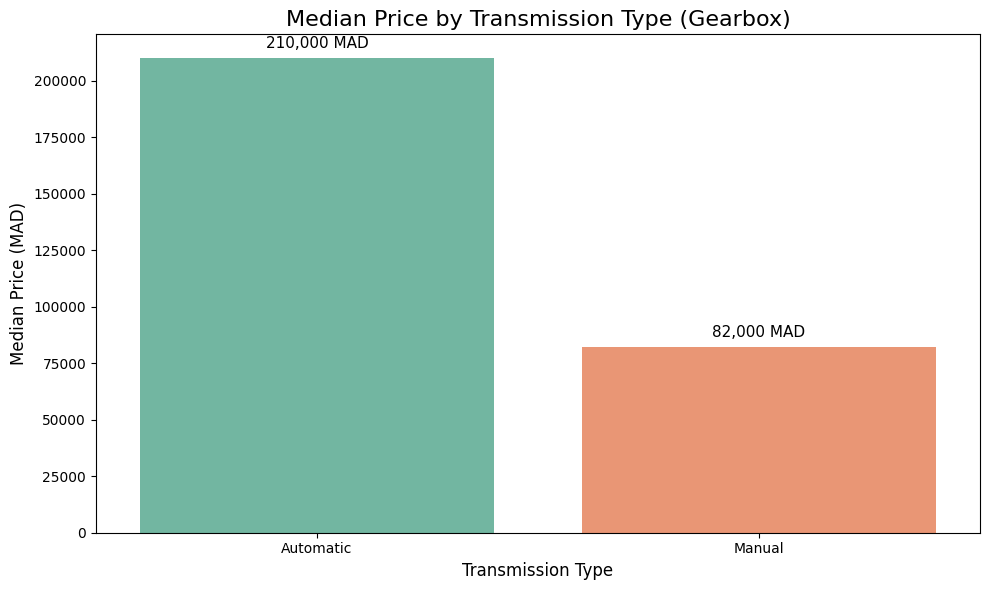

In [136]:
# Calculate median price per gearbox type
median_price_by_gearbox = df.groupby('Gearbox')['Price'].median().reset_index()

# Sort the values so the plot is ordered from highest to lowest price
median_price_by_gearbox = median_price_by_gearbox.sort_values(by='Price', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=median_price_by_gearbox, x='Gearbox', y='Price', palette='Set2', ax=ax)

ax.set_title('Median Price by Transmission Type (Gearbox)', fontsize=16)
ax.set_xlabel('Transmission Type', fontsize=12)
ax.set_ylabel('Median Price (MAD)', fontsize=12)

# Add exact value labels on top of the bars for clarity
for p in ax.patches:
    ax.annotate(f"{p.get_height():,.0f} MAD", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()


4. How does Mileage impact Price ? Do higher-mileage cars sell for significantly less? (Intuitively, the answer is **yes**)

In [143]:
## TO DO LATER

6. Does Condition rating correlate with Price as expected? — Fair < Good < Very Good < Excellent? (We should expect that cars in **Very Good** or **Excellent** conditions to command a higher price)

C:\Users\PC\AppData\Local\Temp\ipykernel_51764\1803093167.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




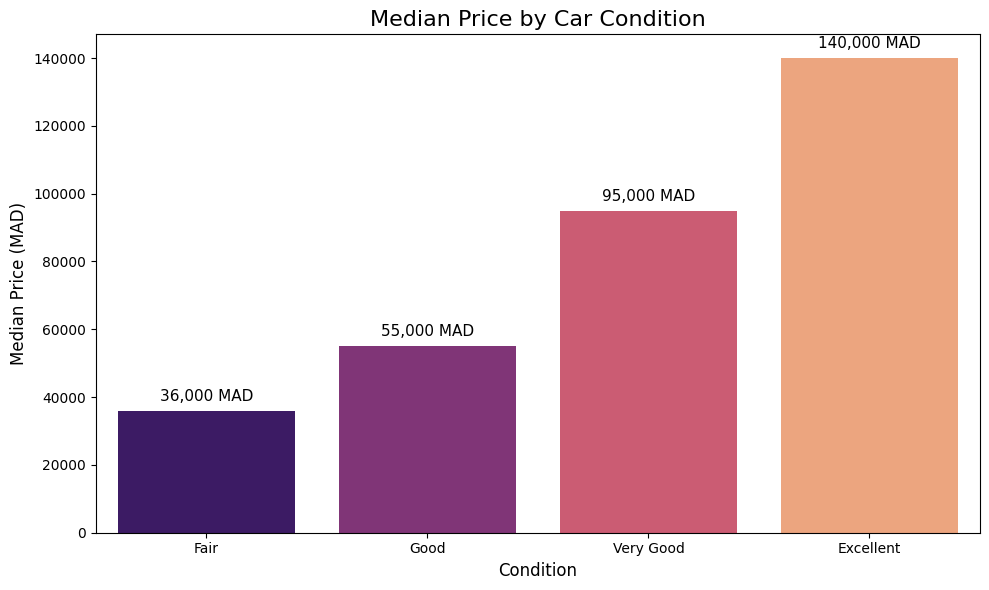

In [144]:
# Calculate median price per condition
median_price_by_condition = df.groupby('Condition')['Price'].median().reset_index()

# Define the logical order of conditions
condition_order = ['Fair', 'Good', 'Very Good', 'Excellent']

fig, ax = plt.subplots(figsize=(10, 6))

# Plot, enforcing the order
sns.barplot(
    data=median_price_by_condition, 
    x='Condition', 
    y='Price', 
    order=condition_order, 
    palette='magma', 
    ax=ax
)

ax.set_title('Median Price by Car Condition', fontsize=16)
ax.set_xlabel('Condition', fontsize=12)
ax.set_ylabel('Median Price (MAD)', fontsize=12)

# Add exact value labels on top of the bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():,.0f} MAD", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()
